## 1. Setup

Just the usual imports. `datasets` is HuggingFace's loader, everything else is standard.

In [4]:
import re
import json
import random
import hashlib
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

# keeping this fixed everywhere so the sampling later is actually reproducible
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams["figure.figsize"] = (8, 4.5)


## 2. Loading the dataset

Using `dipta007/Ganit` from the HF hub. The dataset card calls the splits GanitSFT / GanitRLVR / GanitDEV,
but on the hub itself they're just named `SFT`, `RLVR`, `dev`. We only need the SFT config for the curation step, since that's the one with problem +
solution pairs.

In [5]:
DATASET_ID = "dipta007/Ganit"
SFT_CONFIG = "SFT"

print(f"loading {DATASET_ID} ({SFT_CONFIG}) ...")
ds = load_dataset(DATASET_ID, SFT_CONFIG)

ds = ds[list(ds.keys())[0]] if hasattr(ds, "keys") else ds

df = ds.to_pandas()
df["row_id"] = df.index  # keeping the original position around, useful later for sanity checks
df.shape


loading dipta007/Ganit (SFT) ...


(16868, 9)

## 3. First look at the data

In [6]:
df.head(3)


,problem,source_name,id,bengali_solution,english_solution,correct_counts,difficulty,messages,row_id
0,৮০ মিটার * ৫০ মিটার মাপের একটি আয়তক্ষেত্রাকার ...,numina-math-cot-bn,527116,৬৭৩০.২,6730.2,0,olympiad,[{'content': 'A conversation takes place betwe...,0
1,১০০টি পর্যবেক্ষণের গড় ৩৫০। পরে দেখা যায় যে প্...,numina-math-cot-bn,627574,৪১৩,413,32,easy,[{'content': 'A conversation takes place betwe...,1
2,একটি চেসবোর্ডে (প্রতিটি বর্গক্ষেত্রে সর্বোচ্চ ...,numina-math-cot-bn,309820,৩৮,38,0,olympiad,[{'content': 'A conversation takes place betwe...,2


In [7]:
df.dtypes


problem             object
source_name         object
id                   int64
bengali_solution    object
english_solution    object
correct_counts       int64
difficulty          object
messages            object
row_id               int64
dtype: object

In [8]:
# each row scored with 32 generations from Qwen3-32B, correct_counts is how many of those 32 landed on the right answer
TOTAL_SAMPLES = 32
print("columns:", list(df.columns))
print("solve-rate column (correct_counts) range:", df["correct_counts"].min(), "-", df["correct_counts"].max())


columns: ['problem', 'source_name', 'id', 'bengali_solution', 'english_solution', 'correct_counts', 'difficulty', 'messages', 'row_id']
solve-rate column (correct_counts) range: 0 - 32


## 4. Missing values

Checking both real NaNs and the sneakier case of empty-string fields, which `isnull()` won't catch.

In [9]:
na_counts = df.isnull().sum()
na_counts[na_counts > 0] if na_counts.sum() else print("no NaNs anywhere, good")


no NaNs anywhere, good


In [10]:
# empty/whitespace-only strings in the text-bearing columns, these slip past isnull()
text_cols = [c for c in ["problem", "bengali_solution", "english_solution"] if c in df.columns]
for c in text_cols:
    empties = (df[c].astype(str).str.strip() == "").sum()
    print(f"{c:<20} empty: {empties}")


problem              empty: 0
bengali_solution     empty: 0
english_solution     empty: 0


## 5. Duplicate check

First the boring exact-match version, then something a bit smarter for near-duplicates (same problem, reworded or re-translated).

In [11]:
exact_dupes = df.duplicated(subset=["problem"]).sum()
print(f"exact duplicate problems: {exact_dupes}")


exact duplicate problems: 21


In [12]:
# Ganit stores numbers in both Bengali and Western digits depending on the source, so before comparing any text we need everything on the same footing.
BN_DIGITS = str.maketrans("০১২৩৪৫৬৭৮৯", "0123456789")
NUMBER_RE = re.compile(r"\d+(?:\.\d+)?")

def normalise(text):
    """lowercase + bengali->western digits + strip punctuation, collapse whitespace"""
    if not text:
        return ""
    text = str(text).translate(BN_DIGITS).lower()
    text = re.sub(r"[^\w\s.]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

def numeric_fingerprint(text):
    """
    The numbers inside a word problem survive translation even when every word
    changes, so hashing the sorted set of numbers is a decent proxy for "is this
    the same underlying problem". It's a loose signal on purpose -- it will
    over-flag sometimes, which is fine as long as we eyeball the hits rather than
    auto-deleting on this alone.
    """
    nums = NUMBER_RE.findall(normalise(text))
    if not nums:
        return None
    canon = sorted(str(float(n)).rstrip("0").rstrip(".") for n in nums)
    return hashlib.md5("|".join(canon).encode()).hexdigest()

def token_set(text):
    return set(normalise(text).split())

def jaccard(a, b):
    if not a or not b:
        return 0.0
    return len(a & b) / len(a | b)


In [13]:
# group rows by numeric fingerprint, then only bother comparing tokens within a group since comparing every row against every other row would be way too slow
fp_groups = defaultdict(list)
for i, row in df.iterrows():
    fp = numeric_fingerprint(row["problem"])
    if fp:
        fp_groups[fp].append(i)

near_dupe_pairs = 0
for idxs in fp_groups.values():
    if len(idxs) < 2:
        continue
    for a in range(len(idxs)):
        ta = token_set(df.loc[idxs[a], "problem"])
        for b in range(a + 1, len(idxs)):
            tb = token_set(df.loc[idxs[b], "problem"])
            if jaccard(ta, tb) >= 0.8:
                near_dupe_pairs += 1

print(f"rows sharing a numeric fingerprint with >=1 other row: {sum(len(v) for v in fp_groups.values() if len(v) > 1)}")
print(f"of those, pairs that also cross the 0.8 token-overlap bar (likely true near-dupes): {near_dupe_pairs}")


rows sharing a numeric fingerprint with >=1 other row: 5363
of those, pairs that also cross the 0.8 token-overlap bar (likely true near-dupes): 6


## 6. Class / label distribution

"Class" here isn't a single clean label. The two things that actually matter for this project are the difficulty tier Ganit assigns and which source corpus a problem came from (since the mix is heavily skewed toward machine-translated NuminaMath).

In [14]:
tier_counts = df["difficulty"].value_counts()
tier_counts


difficulty
easy        10065
olympiad     6411
hard          258
medium        134
Name: count, dtype: int64

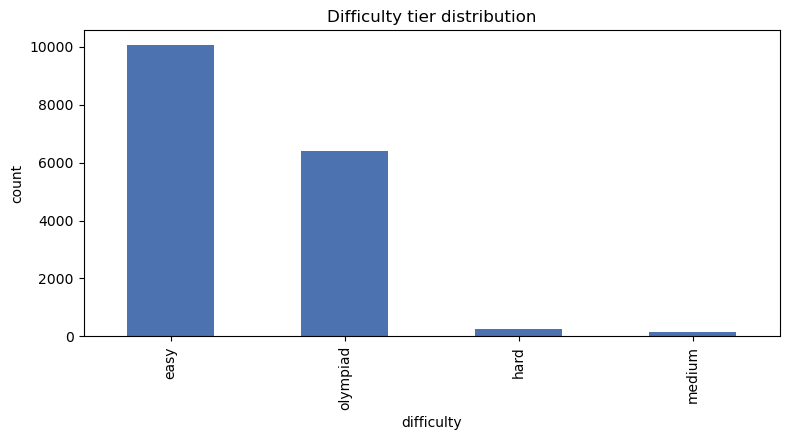

In [15]:
fig, ax = plt.subplots()
tier_counts.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Difficulty tier distribution")
ax.set_xlabel("difficulty")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()


In [16]:
source_counts = df["source_name"].value_counts()
source_counts


source_name
numina-math-cot-bn    13160
SOMADHAN               3487
mCoT-MATH-bn            193
s1k-32-Bangla            28
Name: count, dtype: int64

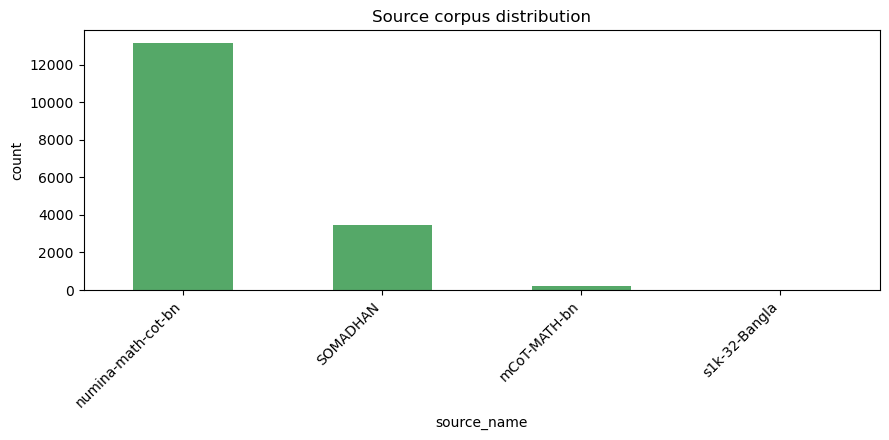

In [17]:
fig, ax = plt.subplots(figsize=(9, 4.5))
source_counts.plot(kind="bar", ax=ax, color="#55A868")
ax.set_title("Source corpus distribution")
ax.set_xlabel("source_name")
ax.set_ylabel("count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


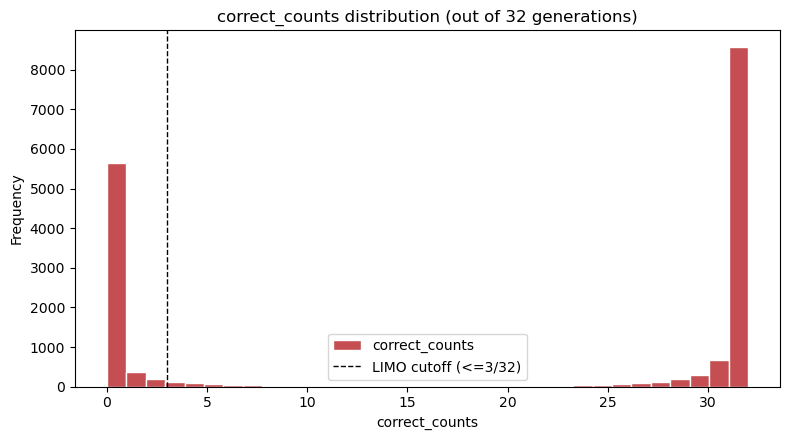

In [18]:
# how many of the 32 generations got each problem right. low correct_counts = hard problem, this is what LIMO-style curation actually filters on later
fig, ax = plt.subplots()
df["correct_counts"].plot(kind="hist", bins=33, ax=ax, color="#C44E52", edgecolor="white")
ax.axvline(3, color="black", linestyle="--", linewidth=1, label="LIMO cutoff (<=3/32)")
ax.set_title("correct_counts distribution (out of 32 generations)")
ax.set_xlabel("correct_counts")
ax.legend()
plt.tight_layout()
plt.show()


In [19]:
# the 0/32 band is checked here. A 32B model missing something every single time usually means either genuine olympiad-level difficulty, or a broken item (wrong gold answer / mangled translation). worth separating those.
zero = df[df["correct_counts"] == 0]
print(f"0/32 band: {len(zero)} rows ({len(zero) / len(df):.1%} of the pool)")
zero["source_name"].value_counts(normalize=True).head()


0/32 band: 5645 rows (33.5% of the pool)


source_name
numina-math-cot-bn    0.917272
SOMADHAN              0.071568
mCoT-MATH-bn          0.006200
s1k-32-Bangla         0.004960
Name: proportion, dtype: float64

##To avoid selecting only very long questions: long wording is not always deeper mathematics

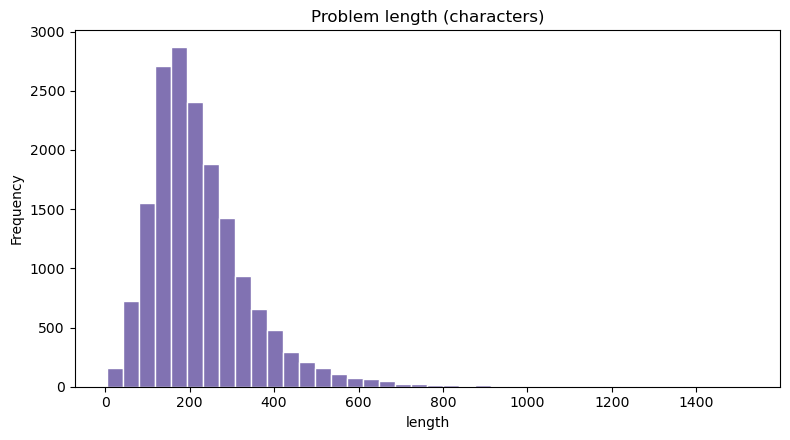

In [20]:
df["problem_len_chars"] = df["problem"].astype(str).str.len()

fig, ax = plt.subplots()
df["problem_len_chars"].plot(kind="hist", bins=40, ax=ax, color="#8172B2", edgecolor="white")
ax.set_title("Problem length (characters)")
ax.set_xlabel("length")
plt.tight_layout()
plt.show()


##Solve rate by difficulty tier


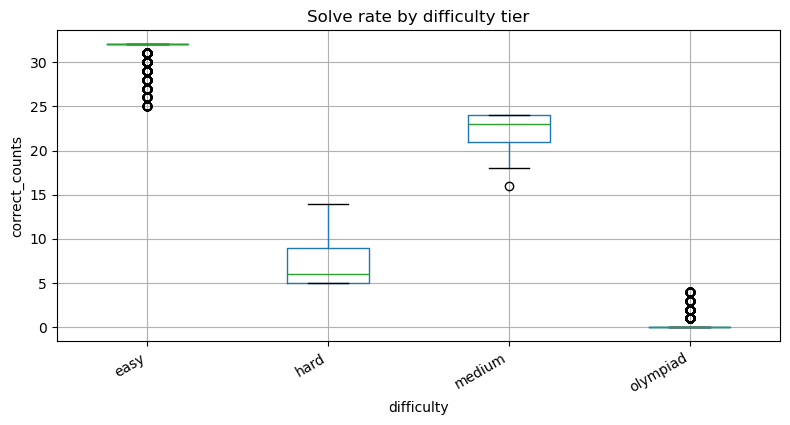

In [21]:
fig, ax = plt.subplots()
df.boxplot(column="correct_counts", by="difficulty", ax=ax)
ax.set_title("Solve rate by difficulty tier")
plt.suptitle("")
ax.set_xlabel("difficulty")
ax.set_ylabel("correct_counts")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 7. Text normalisation (preprocessing)

Quick before/after so it's obvious what `normalise()` is actually doing to the raw text.

In [22]:
sample_row = df.iloc[0]
print("RAW:")
print(sample_row["problem"][:200])
print()
print("NORMALISED:")
print(normalise(sample_row["problem"])[:200])


RAW:
৮০ মিটার * ৫০ মিটার মাপের একটি আয়তক্ষেত্রাকার ঘাসের মাঠের মাঝখানে তিনটি রাস্তা আছে, প্রতিটি রাস্তার চওড়া ১০ মিটার: একটি দৈর্ঘ্যের সাথে সমান্তরাল, একটি প্রস্থের সাথে সমান্তরাল এবং একটি কর্ণীয় রাস্তা 

NORMALISED:
80 ম ট র 50 ম ট র ম প র একট আয়তক ষ ত র ক র ঘ স র ম ঠ র ম ঝখ ন ত নট র স ত আছ প রত ট র স ত র চওড 10 ম ট র একট দ র ঘ য র স থ সম ন তর ল একট প রস থ র স থ সম ন তর ল এব একট কর ণ য র স ত য দ ট ব পর ত শ র ষব ন


## 8. Decontamination against eval benchmarks

In [23]:
from huggingface_hub import notebook_login
notebook_login()

In [24]:
def decontaminate(rows_df, contaminants, jaccard_threshold=0.7):
    """
    two signals, both checked:
      - numeric fingerprint match -> catches re-translations of the same problem
        (this is the one plain n-gram / MinHash dedup would miss)
      - token jaccard >= threshold -> catches near-identical wording
    """
    if not contaminants:
        print("no contaminant files supplied yet -- skipping, don't trust final counts without this")
        return rows_df, []

    bench_fp = defaultdict(list)
    bench_tokens = []
    for name, text in contaminants:
        fp = numeric_fingerprint(text)
        if fp:
            bench_fp[fp].append((name, text))
        bench_tokens.append((name, text, token_set(text)))

    keep_mask, flagged = [], []
    for _, row in rows_df.iterrows():
        problem = row["problem"]
        hit = None
        fp = numeric_fingerprint(problem)
        if fp and fp in bench_fp:
            hit = ("numeric_fingerprint", bench_fp[fp][0][0])
        if hit is None:
            toks = token_set(problem)
            for name, _, btoks in bench_tokens:
                if jaccard(toks, btoks) >= jaccard_threshold:
                    hit = ("token_jaccard", name)
                    break
        if hit:
            flagged.append({"row_id": row["row_id"], "problem": problem, "method": hit[0], "benchmark": hit[1]})
            keep_mask.append(False)
        else:
            keep_mask.append(True)

    kept = rows_df[keep_mask]
    print(f"decontamination: removed {len(flagged)}, kept {len(kept)}")
    return kept, flagged

In [25]:
from datasets import load_dataset
# from huggingface_hub import notebook_login
# notebook_login()  # needed for BenNumEval -- also click "Agree and access repository"
                     # on huggingface.co/datasets/ka05ar/BenNumEval while logged in

contaminants = []

# --- Bn-MGSM ---
try:
    mgsm = load_dataset("juletxara/mgsm", "bn", split="test")
    contaminants += [("Bn-MGSM", row["question"]) for row in mgsm]
    print(f"Bn-MGSM: loaded {len(mgsm)} problems")
except Exception as e:
    print(f"Bn-MGSM: FAILED to load -- {e}")

# --- Bn-MSVAMP ---
try:
    msvamp = load_dataset("Mathoctopus/MSVAMP", "bn", split="test")
    contaminants += [("Bn-MSVAMP", row["m_query"]) for row in msvamp]
    print(f"Bn-MSVAMP: loaded {len(msvamp)} problems")
except Exception as e:
    print(f"Bn-MSVAMP: FAILED to load -- {e}")

# --- BenNumEval ---
bennumeval_configs = ["CA", "DS", "CQ", "FiB", "AWP"]
bennumeval_total = 0
for cfg in bennumeval_configs:
    try:
        task_ds = load_dataset("ka05ar/BenNumEval", cfg, split="test")
        text_col = next((c for c in ["Question", "question", "Problem", "problem", "Text", "text"]
                          if c in task_ds.column_names), None)
        if text_col is None:
            print(f"BenNumEval[{cfg}]: no text column among {task_ds.column_names}, skipping")
            continue
        contaminants += [(f"BenNumEval-{cfg}", row[text_col]) for row in task_ds]
        bennumeval_total += len(task_ds)
    except Exception as e:
        print(f"BenNumEval[{cfg}]: FAILED to load -- {e}")
print(f"BenNumEval: loaded {bennumeval_total} problems across {len(bennumeval_configs)} task types")



print(f"\ntotal contaminant problems loaded: {len(contaminants)}")

README.md:   0%|          | 0.00/13.0k [00:00<?, ?B/s]

C:\anaconda\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\PC\.cache\huggingface\hub\datasets--juletxara--mgsm. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


bn/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 7.65kB            

bn/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

bn/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 62.0kB            

...

Task4%28FiB%29.csv:   0%|          | 0.00/221k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/665 [00:00<?, ? examples/s]

Task6%28AWP%29.csv:   0%|          | 0.00/217k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/650 [00:00<?, ? examples/s]

BenNumEval: loaded 2830 problems across 5 task types

total contaminant problems loaded: 4080


In [26]:
pool_df, flagged_contam = decontaminate(df, contaminants)

decontamination: removed 3315, kept 13553


## 9. Difficulty filtering (LIMO-style hard subset)

In [29]:
MIN_CORRECT, MAX_CORRECT = 1, 16

before_n = len(pool_df)
pool_df = pool_df[(pool_df["correct_counts"] >= MIN_CORRECT) & (pool_df["correct_counts"] <= MAX_CORRECT)]
print(f"difficulty window {MIN_CORRECT}-{MAX_CORRECT}/{TOTAL_SAMPLES}: {before_n} -> {len(pool_df)} rows")


difficulty window 1-16/32: 13553 -> 873 rows


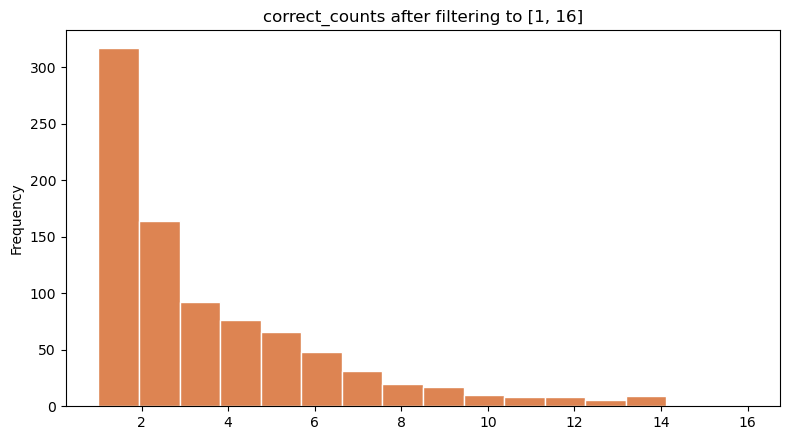

In [30]:
fig, ax = plt.subplots()
pool_df["correct_counts"].plot(kind="hist", bins=MAX_CORRECT - MIN_CORRECT + 1, ax=ax, color="#DD8452", edgecolor="white")
ax.set_title(f"correct_counts after filtering to [{MIN_CORRECT}, {MAX_CORRECT}]")
plt.tight_layout()
plt.show()


## 10. Near-duplicate removal

In [31]:
def dedup(rows_df, jaccard_threshold=0.8):
    seen_fp = {}
    keep_flags = []
    dropped = 0
    for _, row in rows_df.iterrows():
        fp = numeric_fingerprint(row["problem"])
        toks = token_set(row["problem"])
        is_dup = False
        if fp and fp in seen_fp:
            for other_toks in seen_fp[fp]:
                if jaccard(toks, other_toks) >= jaccard_threshold:
                    is_dup = True
                    break
        if is_dup:
            dropped += 1
            keep_flags.append(False)
        else:
            keep_flags.append(True)
            if fp:
                seen_fp.setdefault(fp, []).append(toks)
    kept = rows_df[keep_flags]
    print(f"near-duplicate removal: dropped {dropped}, kept {len(kept)}")
    return kept

pool_df = dedup(pool_df)


near-duplicate removal: dropped 0, kept 873


## 14. Freezing the curated set

In [34]:
import os
import json
import numpy as np

os.makedirs("curated", exist_ok=True)

def to_plain(value):
    """Convert NumPy/Pandas values into normal JSON-safe Python values."""
    if isinstance(value, np.ndarray):
        return [to_plain(v) for v in value.tolist()]
    if isinstance(value, dict):
        return {k: to_plain(v) for k, v in value.items()}
    if isinstance(value, list):
        return [to_plain(v) for v in value]
    if isinstance(value, np.integer):
        return int(value)
    if isinstance(value, np.floating):
        return float(value)
    if isinstance(value, np.bool_):
        return bool(value)
    return value

tag = f"n{TARGET_N}_c{MIN_CORRECT}-{MAX_CORRECT}_seed{SEED}"

# Safety checks: do not accidentally save duplicates or an unexpected size.
assert curated_df["id"].nunique() == len(curated_df), "Duplicate example IDs found."
assert len(curated_df) <= len(pool_df), "Curated set is larger than the filtered pool."

with open(f"curated/ganit_limo_{tag}.ids.json", "w", encoding="utf-8") as f:
    json.dump({
        "dataset": DATASET_ID,
        "config": SFT_CONFIG,
        "n": len(curated_df),
        "min_correct": MIN_CORRECT,
        "max_correct": MAX_CORRECT,
        "seed": SEED,
        "ids": sorted(curated_df["id"].tolist()),
    }, f, ensure_ascii=False, indent=2)

with open(f"curated/ganit_limo_{tag}.jsonl", "w", encoding="utf-8") as f:
    for _, row in curated_df.iterrows():
        example_id = row["id"] if "id" in row.index else row["row_id"]

        record = {
            "id": to_plain(example_id),
            "problem": row["problem"],
            "messages": to_plain(row.get("messages")),
            "bengali_solution": row.get("bengali_solution"),
            "english_solution": row.get("english_solution"),
            "difficulty": row["difficulty"],
            "correct_counts": int(row["correct_counts"]),
            "source_name": row["source_name"],
        }

        f.write(json.dumps(record, ensure_ascii=False) + "\n")

print(f"Wrote curated/ganit_limo_{tag}.ids.json")
print(f"Wrote curated/ganit_limo_{tag}.jsonl")

Wrote curated/ganit_limo_n1000_c1-16_seed42.ids.json
Wrote curated/ganit_limo_n1000_c1-16_seed42.jsonl
